In [1]:
import numpy as np
np.bool = np.bool_ 
import pandas as pd
import os
from tqdm import tqdm

import mxnet as mx
from mxnet import gluon
from mxnet import autograd
from mxnet import image

import sys
sys.path.append('resuneta/src')
sys.path.append('decode/FracTAL_ResUNet/models/semanticsegmentation')
sys.path.append('decode/FracTAL_ResUNet/nn/loss')
sys.path.append('autogeobound/MXNet-ResUNeta/')

from bound_dist import get_distance, get_boundary
from FracTAL_ResUNet import FracTAL_ResUNet_cmtsk
#from ftnmt_loss import ftnmt_loss
from datasets import *

from sklearn.metrics import matthews_corrcoef
from scipy.stats import pearsonr

import random

import rasterio
from rasterio.enums import ColorInterp
from rasterio.features import shapes
from scipy import ndimage

import matplotlib.pyplot as plt
%matplotlib inline

import higra as hg
import torch
import pickle

import itertools

import imageio.v3 as imageio
from skimage.color import label2rgb
import cv2
from skimage.segmentation import mark_boundaries
from skimage.segmentation import find_boundaries

from shapely.geometry import shape
import shapely
from shapely import Polygon, orient_polygons
from shapely.plotting import plot_polygon
from shapely import ops

import ast

import pyproj

In [3]:
file = open('calibration_data/conformal_results_final.pkl', 'rb')
results_table = pickle.load(file)
file.close()

results_table = results_table[results_table['data_split']=='test'].reset_index()

In [4]:
baseline_predictions = pd.read_csv('baseline_comparison_data/calibration_data_baseline_predictions.csv')

In [5]:
data = pd.merge(results_table, baseline_predictions, on='image_filename')[['image_filename', 'true_field_epsg5070', 'taylor_geospatial_prediction', 'usda_prediction']]
data = data.reset_index()

In [6]:
transform = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True).transform

def compute_transformed_pred_and_IOU(pred, true_field):
    if isinstance(pred, str):
        pred = Polygon(ast.literal_eval(pred)['coordinates'][0])
        pred = shapely.ops.transform(transform, pred)
        IOU = true_field.intersection(pred).area / true_field.union(pred).area
        #plot_polygon(true_field, color='red')
        #plot_polygon(pred)
        #plt.show()
    else:
        pred = np.nan
        IOU = 0
    return pred, IOU

true_fields = data['true_field_epsg5070']
preds1 = data['taylor_geospatial_prediction']
preds1_epsg5070 = []
IOUs1 = []
preds2 = data['usda_prediction']
preds2_epsg5070 = []
IOUs2 = []
for i in tqdm(range(len(true_fields))):
    true_field = true_fields[i]
    pred1 = preds1[i]
    pred2 = preds2[i]
    pred1, IOU1 = compute_transformed_pred_and_IOU(pred1, true_field)
    pred2, IOU2 = compute_transformed_pred_and_IOU(pred2, true_field)
        
    preds1_epsg5070.append(pred1)
    IOUs1.append(IOU1)
    preds2_epsg5070.append(pred2)
    IOUs2.append(IOU2)
    
data['taylor_geospatial_prediction_epsg5070'] = preds1_epsg5070
data['taylor_geospatial_IOU'] = IOUs1
data['usda_prediction_epsg5070'] = preds2_epsg5070
data['usda_IOU'] = IOUs2

100%|██████████| 150/150 [00:01<00:00, 87.00it/s] 


In [7]:
data

,index,image_filename,true_field_epsg5070,taylor_geospatial_prediction,usda_prediction,taylor_geospatial_prediction_epsg5070,taylor_geospatial_IOU,usda_prediction_epsg5070,usda_IOU
0,0,calibration_data/images/0004.tif,POLYGON ((-384979.60558642953 2553182.42175152...,"{""type"":""Polygon"",""coordinates"":[[[-100.934711...","{""type"":""Polygon"",""coordinates"":[[[-100.955780...",POLYGON ((-383218.04494304373 2555515.40381496...,0.124619,POLYGON ((-384978.14591714257 2553197.43031751...,0.625701
1,1,calibration_data/images/0007.tif,POLYGON ((618274.3436819421 1319406.9693449077...,NaN,"{""type"":""Polygon"",""coordinates"":[[[-89.2040604...",NaN,0.000000,POLYGON ((616766.6474736488 1318890.4309811231...,0.103055
2,2,calibration_data/images/0008.tif,POLYGON ((-622662.6370426221 2692648.040321153...,"{""type"":""Polygon"",""coordinates"":[[[-104.156417...","{""type"":""Polygon"",""coordinates"":[[[-104.150068...",POLYGON ((-622603.688078969 2692588.1410771417...,0.107588,POLYGON ((-622156.6981382059 2692122.313056052...,0.482751
3,3,calibration_data/images/0009.tif,POLYGON ((-519685.07275860006 2610590.66512130...,"{""type"":""Polygon"",""coordinates"":[[[-102.725316...","{""type"":""Polygon"",""coordinates"":[[[-102.726878...",POLYGON ((-518719.1041277346 2611331.014052937...,0.645600,POLYGON ((-518861.15970181784 2611032.22119198...,0.641821
4,4,calibration_data/images/0011.tif,POLYGON ((474562.7120643052 2416328.7152097626...,"{""type"":""Polygon"",""coordinates"":[[[-90.0035124...","{""type"":""Polygon"",""coordinates"":[[[-89.9899649...","POLYGON ((474653.1587283598 2416549.055791002,...",0.355251,POLYGON ((475713.76744468894 2416779.670987342...,0.341094
...,...,...,...,...,...,...,...,...,...
145,145,calibration_data/images/0495.tif,POLYGON ((197358.51923777506 1846655.572070742...,"{""type"":""Polygon"",""coordinates"":[[[-93.6778778...","{""type"":""Polygon"",""coordinates"":[[[-93.6776769...",POLYGON ((197528.45280412218 1846661.808488539...,0.517694,"POLYGON ((197546.223242701 1846634.1975324957,...",0.727332
146,146,calibration_data/images/0500.tif,POLYGON ((-211405.1584179754 2189297.417919673...,"{""type"":""Polygon"",""coordinates"":[[[-98.5914648...","{""type"":""Polygon"",""coordinates"":[[[-98.5910715...",POLYGON ((-211104.78359437225 2189307.11371967...,0.524559,POLYGON ((-211053.03324304565 2190029.38886671...,0.028326
147,147,calibration_data/images/0373.tif,POLYGON ((1575929.4265827693 1488637.825008144...,"{""type"":""Polygon"",""coordinates"":[[[-78.4563406...","{""type"":""Polygon"",""coordinates"":[[[-78.4576693...",POLYGON ((1576017.9534338568 1488920.483328428...,0.216252,POLYGON ((1575939.3161154378 1488687.620263637...,0.627358
148,148,calibration_data/images/0117.tif,POLYGON ((-2253103.318126104 1830118.850384111...,"{""type"":""Polygon"",""coordinates"":[[[-121.782017...",NaN,POLYGON ((-2252686.257913177 1830195.615028341...,0.180393,NaN,0.000000


In [8]:
data.to_csv('baseline_comparison_data/test_results.csv', index=False)

# Taylor Geospatial baseline

In [9]:
print("Coverage:", len(data[data["taylor_geospatial_IOU"] > 0.8])/len(data))
print("mean IOU:", np.mean(data["taylor_geospatial_IOU"]))
print("median IOU:", np.median(data["taylor_geospatial_IOU"]))

Coverage: 0.2
mean IOU: 0.41230694621648406
median IOU: 0.33897721412465


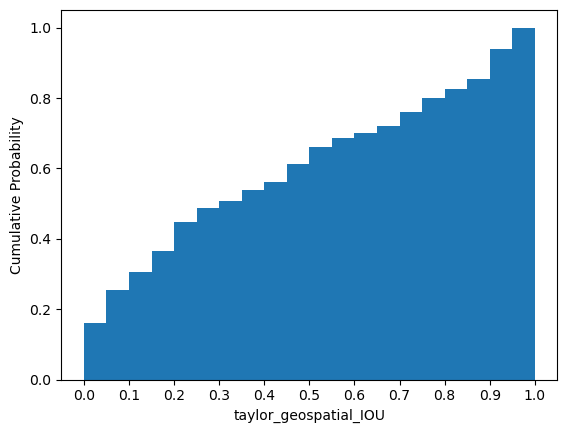

In [10]:
plt.hist(data["taylor_geospatial_IOU"], bins=np.arange(0, 1.01, .05), density=True, cumulative=True)
plt.xlabel("taylor_geospatial_IOU")
plt.ylabel("Cumulative Probability")
plt.xticks(np.arange(0, 1.01, 0.1))
plt.show()

In [11]:
data["taylor_geospatial_prediction_epsg5070"].isna().sum()

18

# USDA baseline

In [12]:
print("Coverage:", len(data[data["usda_IOU"] > 0.8])/len(data))
print("mean IOU:", np.mean(data["usda_IOU"]))
print("median IOU:", np.median(data["usda_IOU"]))

Coverage: 0.18666666666666668
mean IOU: 0.4286903152986359
median IOU: 0.43505393339215587


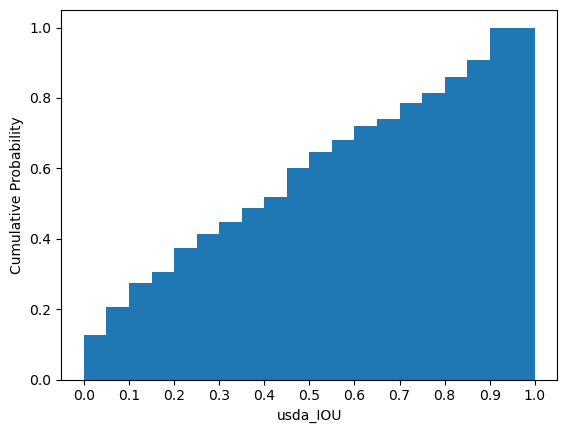

In [13]:
plt.hist(data["usda_IOU"], bins=np.arange(0, 1.01, .05), density=True, cumulative=True)
plt.xlabel("usda_IOU")
plt.ylabel("Cumulative Probability")
plt.xticks(np.arange(0, 1.01, 0.1))
plt.show()

In [14]:
data["usda_prediction_epsg5070"].isna().sum()

7

PearsonRResult(statistic=0.2558117089514151, pvalue=0.0015799991257676236)


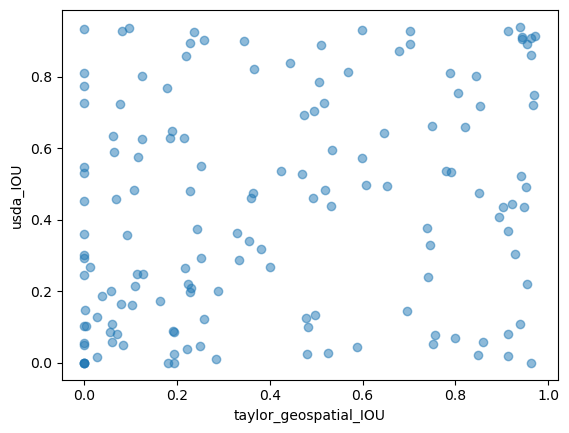

In [15]:
print(pearsonr(data["taylor_geospatial_IOU"], data["usda_IOU"]))
plt.scatter(data["taylor_geospatial_IOU"], data["usda_IOU"], alpha=0.5)
plt.xlabel("taylor_geospatial_IOU")
plt.ylabel("usda_IOU")
plt.show()